# InsightIQ — AI-Powered Business Decision Intelligence Platform

**Author:** Sakshi Wadodkar  
**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship  
**Dataset:** Tableau Sample Superstore (Official)  
**Date:** 2026

---

## 1. Executive Overview

**InsightIQ** is an AI-powered business decision intelligence platform built on the official Tableau Sample Superstore dataset. The platform combines descriptive analytics, predictive machine learning, model explainability, anomaly detection, and what-if decision simulation to help business stakeholders answer:

> *"Given historical business data, what is happening in the business, what patterns and risks can be identified, what may happen next, and how might different business decisions affect expected outcomes?"*

## 2. Business Problem

Key challenges addressed:
- **Unclear profitability drivers** — which products, segments, and regions generate or erode profit?
- **Discount strategy risk** — are discount levels helping or harming profitability?
- **Sales forecasting** — what are expected future sales based on historical patterns?
- **Anomaly blind spots** — are there unusual business events requiring investigation?
- **Decision uncertainty** — how might a change in discount strategy affect outcomes?

## 3. Project Objectives

1. Perform comprehensive EDA on the Superstore dataset
2. Calculate and visualise key business KPIs
3. Analyse customer, product, and regional performance
4. Investigate discount–profitability relationships
5. Build and evaluate a predictive sales model
6. Apply model explainability techniques
7. Detect anomalous business performance
8. Analyse product returns
9. Build an interactive what-if Decision Simulator
10. Provide data-supported business recommendations

## 4. Analytical Questions

1. What are overall sales, profit, and quantity trends over time?
2. Which customer segments, product categories, and regions are most/least profitable?
3. How does the discount level relate to profit margins historically?
4. Can we predict future monthly sales from historical patterns?
5. Which features most influence sales predictions?
6. Are there anomalous months or transactions in business performance?
7. What is the product return rate and how is it distributed?
8. Under different discount scenarios, what outcomes does the model estimate?

## 5. Dataset Description

| Attribute | Value |
|-----------|-------|
| **File** | `sample_-_superstore.xls` |
| **Primary Sheet** | Orders |
| **Supporting Sheets** | Returns, People |
| **Time Period** | 2023–2026 |
| **Geography** | United States and Canada |

## 6. Dataset Source

**Official Tableau Sample Data:** https://public.tableau.com/app/resources/sample-data  
> Used for educational purposes under the IBM SkillsBuild internship programme. No ownership claimed.

## 7. Technologies Used

| Technology | Purpose |
|-----------|--------|
| Python 3.12 | Core programming language |
| pandas | Data manipulation and analysis |
| numpy | Numerical computations |
| matplotlib | Static visualisations |
| seaborn | Statistical visualisations |
| scikit-learn | ML — Random Forest, Isolation Forest |
| xlrd | Reading .xls Excel files |
| Jupyter Notebook | Interactive analytical environment |

## 8. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}')
print('Libraries loaded successfully.')

pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2
Libraries loaded successfully.


## 9. Load Dataset

In [2]:
DATASET_PATH = 'sample_-_superstore.xls'

orders_raw  = pd.read_excel(DATASET_PATH, sheet_name='Orders',  engine='xlrd')
returns_raw = pd.read_excel(DATASET_PATH, sheet_name='Returns', engine='xlrd')
people_raw  = pd.read_excel(DATASET_PATH, sheet_name='People',  engine='xlrd')

print(f'Orders  : {orders_raw.shape[0]:,} rows x {orders_raw.shape[1]} columns')
print(f'Returns : {returns_raw.shape[0]:,} rows x {returns_raw.shape[1]} columns')
print(f'People  : {people_raw.shape[0]:,} rows x {people_raw.shape[1]} columns')

Orders  : 10,194 rows x 21 columns
Returns : 296 rows x 2 columns
People  : 4 rows x 2 columns


## 10. Data Understanding

In [3]:
print('-- Orders sheet: first 5 rows --')
display(orders_raw.head())
print('\n-- Column dtypes --')
print(orders_raw.dtypes.to_string())

-- Orders sheet: first 5 rows --


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840



-- Column dtypes --
Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State/Province               str
Postal Code               object
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64


In [4]:
print('-- Returns sheet --')
display(returns_raw.head())
print('\n-- People sheet --')
display(people_raw)

-- Returns sheet --


,Order ID,Returned
0,US-2023-100762,Yes
1,US-2023-100867,Yes
2,US-2023-102652,Yes
3,US-2023-103373,Yes
4,US-2023-103744,Yes



-- People sheet --


,Regional Manager,Region
0,Sadie Pawthorne,West
1,Chuck Magee,East
2,Roxanne Rodriguez,Central
3,Fred Suzuki,South


## 11. Data Quality Assessment

In [5]:
def data_quality_report(df, name='DataFrame'):
    print(f'\n== {name} ==')
    print(f'  Rows          : {df.shape[0]:,}')
    print(f'  Columns       : {df.shape[1]}')
    print(f'  Duplicate rows: {df.duplicated().sum():,}')
    mv = df.isnull().sum()
    mv = mv[mv > 0]
    if mv.empty:
        print('  Missing values: None')
    else:
        print('  Missing values:')
        for col, cnt in mv.items():
            print(f'    {col}: {cnt:,} ({cnt/len(df)*100:.1f}%)')

data_quality_report(orders_raw,  'Orders')
data_quality_report(returns_raw, 'Returns')
data_quality_report(people_raw,  'People')


== Orders ==
  Rows          : 10,194
  Columns       : 21
  Duplicate rows: 0
  Missing values: None

== Returns ==
  Rows          : 296
  Columns       : 2
  Duplicate rows: 0
  Missing values: None

== People ==
  Rows          : 4
  Columns       : 2
  Duplicate rows: 0
  Missing values: None


In [6]:
cat_cols = ['Ship Mode', 'Segment', 'Country/Region', 'Region', 'Category', 'Sub-Category']
print('Categorical cardinality (Orders):')
for col in cat_cols:
    vals = sorted(orders_raw[col].dropna().unique())
    print(f'  {col} ({len(vals)}): {vals}')

Categorical cardinality (Orders):
  Ship Mode (4): ['First Class', 'Same Day', 'Second Class', 'Standard Class']
  Segment (3): ['Consumer', 'Corporate', 'Home Office']
  Country/Region (2): ['Canada', 'United States']
  Region (4): ['Central', 'East', 'South', 'West']
  Category (3): ['Furniture', 'Office Supplies', 'Technology']
  Sub-Category (17): ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']


In [7]:
order_dates = pd.to_datetime(orders_raw['Order Date'], dayfirst=True, errors='coerce')
print(f'Order Date range : {order_dates.min().date()} to {order_dates.max().date()}')
ship_dates = pd.to_datetime(orders_raw['Ship Date'], dayfirst=True, errors='coerce')
print(f'Ship Date range  : {ship_dates.min().date()} to {ship_dates.max().date()}')
print(f'Unique Orders    : {orders_raw["Order ID"].nunique():,}')
print(f'Unique Customers : {orders_raw["Customer ID"].nunique():,}')
print(f'Unique Products  : {orders_raw["Product Name"].nunique():,}')

Order Date range : 2023-01-03 to 2026-12-30
Ship Date range  : 2023-01-07 to 2027-01-05
Unique Orders    : 5,111
Unique Customers : 804
Unique Products  : 1,849


## 12. Data Cleaning and Preprocessing

In [8]:
orders = orders_raw.copy()

# 1. Parse dates
orders['Order Date'] = pd.to_datetime(orders['Order Date'], dayfirst=True, errors='coerce')
orders['Ship Date']  = pd.to_datetime(orders['Ship Date'],  dayfirst=True, errors='coerce')

# 2. Derived temporal features
orders['Order Year']     = orders['Order Date'].dt.year
orders['Order Month']    = orders['Order Date'].dt.month
orders['Order Quarter']  = orders['Order Date'].dt.quarter
orders['Year-Month']     = orders['Order Date'].dt.to_period('M')
orders['Lead Time Days'] = (orders['Ship Date'] - orders['Order Date']).dt.days

# 3. Derived business metrics
orders['Profit Margin'] = np.where(
    orders['Sales'] != 0,
    orders['Profit'] / orders['Sales'],
    0.0
)

# 4. Postal Code: keep as string (dataset has both US numeric and Canadian alphanumeric codes)
orders['Postal Code'] = orders['Postal Code'].astype(str).str.strip()
# Zero-pad US numeric codes to 5 digits
def normalise_postal(pc):
    pc = pc.strip()
    if pc.isdigit():
        return pc.zfill(5)
    return pc  # keep Canadian codes as-is (e.g. M7A)
orders['Postal Code'] = orders['Postal Code'].apply(normalise_postal)

# 5. Validate numeric columns
for col in ['Sales', 'Quantity', 'Discount', 'Profit']:
    orders[col] = pd.to_numeric(orders[col], errors='coerce')

# 6. Drop duplicate rows
n_before = len(orders)
orders.drop_duplicates(inplace=True)
orders.reset_index(drop=True, inplace=True)
print(f'Duplicate rows removed : {n_before - len(orders)}')

# 7. Strip whitespace from string columns
str_cols = orders.select_dtypes('object').columns
for col in str_cols:
    orders[col] = orders[col].str.strip()

# 8. Check remaining nulls
num_null = orders[['Sales','Profit','Quantity','Discount']].isnull().sum().sum()
print(f'Remaining nulls in key numeric cols: {num_null}')
print(f'Clean dataset: {orders.shape[0]:,} rows x {orders.shape[1]} columns')
display(orders.dtypes)

Duplicate rows removed : 0
Remaining nulls in key numeric cols: 0
Clean dataset: 10,194 rows x 27 columns


Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State/Province               str
Postal Code                  str
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Order Year                 int32
Order Month                int32
Order Quarter              int32
Year-Month             period[M]
Lead Time Days             int64
Profit Margin            float64
dtype: object

In [9]:
# Returns join — flag order lines belonging to returned orders
returns = returns_raw.copy()
returns.columns = returns.columns.str.strip()
returns['Returned'] = returns['Returned'].astype(str).str.strip()
returned_order_ids = set(returns[returns['Returned'] == 'Yes']['Order ID'].unique())
orders['Is Returned'] = orders['Order ID'].isin(returned_order_ids).astype(int)
print(f'Returned Order IDs (from Returns sheet): {len(returned_order_ids):,}')
print(f'Order lines flagged as returned          : {orders["Is Returned"].sum():,}')

# People join — regional manager enrichment
people = people_raw.copy()
people.columns = people.columns.str.strip()
# Column names are 'Regional Manager' and 'Region'
print(f'\nPeople columns: {list(people.columns)}')
display(people)
orders = orders.merge(people[['Region', 'Regional Manager']], on='Region', how='left')
print(f'Regional Manager nulls after join: {orders["Regional Manager"].isnull().sum()}')

Returned Order IDs (from Returns sheet): 296


Order lines flagged as returned          : 800

People columns: ['Regional Manager', 'Region']


,Regional Manager,Region
0,Sadie Pawthorne,West
1,Chuck Magee,East
2,Roxanne Rodriguez,Central
3,Fred Suzuki,South


Regional Manager nulls after join: 0


## 13. Exploratory Data Analysis

## 14. Business KPI Analysis

In [10]:
total_sales     = orders['Sales'].sum()
total_profit    = orders['Profit'].sum()
total_quantity  = int(orders['Quantity'].sum())
num_orders      = orders['Order ID'].nunique()
num_customers   = orders['Customer ID'].nunique()
avg_order_value = total_sales / num_orders
avg_discount    = orders['Discount'].mean()
overall_margin  = total_profit / total_sales

kpis = {
    'Total Sales':           f'${total_sales:,.2f}',
    'Total Profit':          f'${total_profit:,.2f}',
    'Total Quantity':        f'{total_quantity:,}',
    'No. of Orders':         f'{num_orders:,}',
    'No. of Customers':      f'{num_customers:,}',
    'Avg Order Value':       f'${avg_order_value:,.2f}',
    'Avg Discount':          f'{avg_discount*100:.1f}%',
    'Overall Profit Margin': f'{overall_margin*100:.1f}%',
}

print('=' * 50)
print('   InsightIQ -- Business KPI Summary')
print('=' * 50)
for k, v in kpis.items():
    print(f'  {k:<28} {v:>12}')
print('=' * 50)

   InsightIQ -- Business KPI Summary
  Total Sales                  $2,326,534.35
  Total Profit                  $292,296.81
  Total Quantity                     38,654
  No. of Orders                       5,111
  No. of Customers                      804
  Avg Order Value                   $455.20
  Avg Discount                        15.5%
  Overall Profit Margin               12.6%


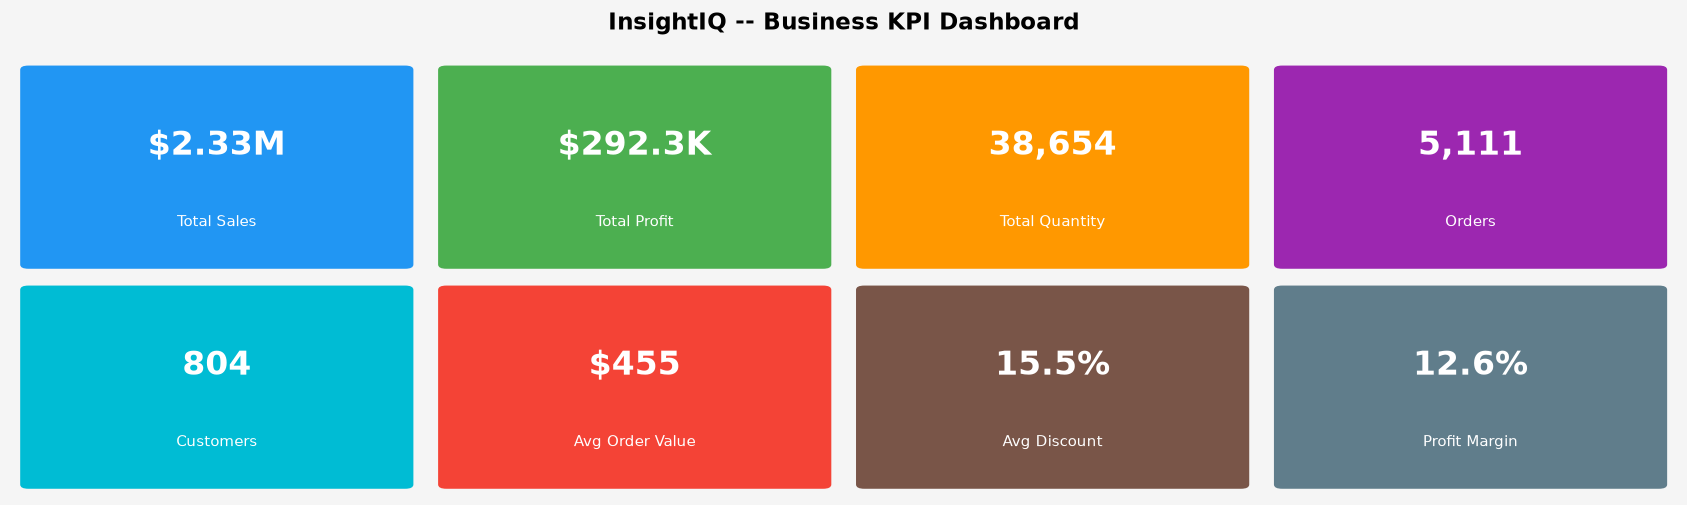

In [11]:
import matplotlib.patches as mpatches

kpi_cards = [
    ('Total Sales',        f'${total_sales/1e6:.2f}M',    '#2196F3'),
    ('Total Profit',       f'${total_profit/1e3:.1f}K',   '#4CAF50'),
    ('Total Quantity',     f'{total_quantity:,}',           '#FF9800'),
    ('Orders',             f'{num_orders:,}',               '#9C27B0'),
    ('Customers',          f'{num_customers:,}',            '#00BCD4'),
    ('Avg Order Value',    f'${avg_order_value:.0f}',       '#F44336'),
    ('Avg Discount',       f'{avg_discount*100:.1f}%',      '#795548'),
    ('Profit Margin',      f'{overall_margin*100:.1f}%',    '#607D8B'),
]

# Use default style context to prevent seaborn whitegrid from overriding
# the colored card backgrounds (set_facecolor is overridden by rcParams)
with plt.style.context('default'):
    fig, axes = plt.subplots(2, 4, figsize=(14, 4))
    fig.patch.set_facecolor('#F5F5F5')
    axes = axes.flatten()

    for ax, (label, value, color) in zip(axes, kpi_cards):
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        rect = mpatches.FancyBboxPatch(
            (0.04, 0.04), 0.92, 0.92,
            boxstyle='round,pad=0.02', linewidth=0,
            facecolor=color, transform=ax.transAxes, clip_on=False, zorder=1
        )
        ax.add_patch(rect)
        ax.text(0.5, 0.60, value, ha='center', va='center',
                fontsize=20, fontweight='bold', color='white',
                transform=ax.transAxes, zorder=2)
        ax.text(0.5, 0.24, label, ha='center', va='center',
                fontsize=9, color='white',
                transform=ax.transAxes, zorder=2)

    fig.suptitle('InsightIQ -- Business KPI Dashboard',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout(pad=0.5)
    plt.savefig('kpi_dashboard.png', dpi=120, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()

**Interpretation:** The business generated substantial total sales with a positive overall profit margin. The average discount level warrants further investigation into its relationship with profitability.

## 15. Customer Analytics

In [12]:
cust_agg = orders.groupby('Customer ID').agg(
    Total_Sales  =('Sales',    'sum'),
    Total_Profit =('Profit',   'sum'),
    Num_Orders   =('Order ID', 'nunique'),
    Avg_Discount =('Discount', 'mean'),
).reset_index()
cust_agg['AOV'] = cust_agg['Total_Sales'] / cust_agg['Num_Orders']

print('Customer-level statistics:')
print(cust_agg[['Total_Sales','Total_Profit','Num_Orders','AOV']].describe().round(2).to_string())

Customer-level statistics:
       Total_Sales  Total_Profit  Num_Orders      AOV
count       804.00        804.00      804.00   804.00
mean       2893.70        363.55        6.36   454.30
std        2653.78        893.03        2.66   432.33
min           4.83      -6626.39        1.00     2.42
25%        1084.54         35.38        5.00   206.90
50%        2243.39        226.95        6.00   358.89
75%        3790.81        564.09        8.00   548.07
max       25043.05       8981.32       17.00  5008.61


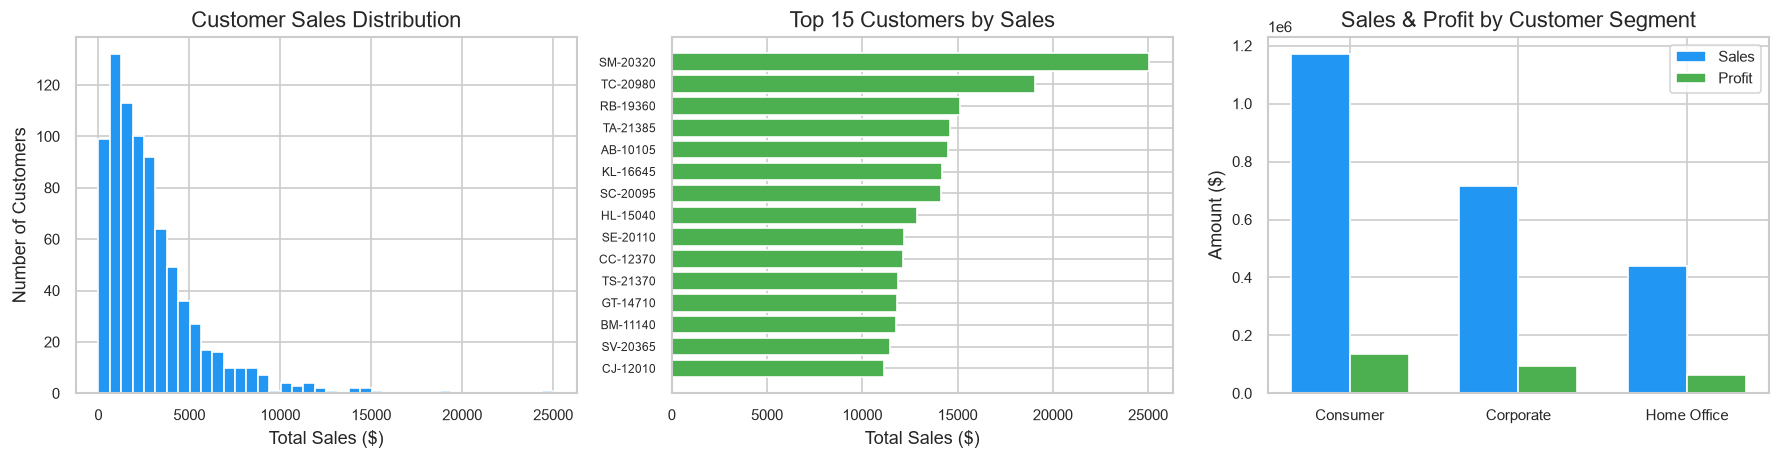

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(cust_agg['Total_Sales'], bins=40, color='#2196F3', edgecolor='white')
axes[0].set_title('Customer Sales Distribution')
axes[0].set_xlabel('Total Sales ($)')
axes[0].set_ylabel('Number of Customers')

top15 = cust_agg.nlargest(15, 'Total_Sales')
axes[1].barh(range(15), top15['Total_Sales'].values, color='#4CAF50')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top15['Customer ID'].values, fontsize=7)
axes[1].set_title('Top 15 Customers by Sales')
axes[1].set_xlabel('Total Sales ($)')
axes[1].invert_yaxis()

seg = orders.groupby('Segment').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()
x = np.arange(len(seg))
w = 0.35
axes[2].bar(x - w/2, seg['Sales'],  w, label='Sales',  color='#2196F3')
axes[2].bar(x + w/2, seg['Profit'], w, label='Profit', color='#4CAF50')
axes[2].set_xticks(x)
axes[2].set_xticklabels(seg['Segment'].values)
axes[2].set_title('Sales & Profit by Customer Segment')
axes[2].set_ylabel('Amount ($)')
axes[2].legend()

plt.tight_layout()
plt.savefig('customer_analytics.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
seg_aov = orders.groupby('Segment').apply(
    lambda g: g['Sales'].sum() / g['Order ID'].nunique(), include_groups=False
).reset_index(name='AOV')
print('Average Order Value by Segment:')
print(seg_aov.to_string(index=False))

Average Order Value by Segment:
    Segment        AOV
   Consumer 445.456540
  Corporate 461.215293
Home Office 472.683601


**Interpretation:** Customer sales follow a right-skewed distribution — a small number of customers contribute a disproportionately large share of revenue. The Consumer segment generates the highest total sales volume.

## 16. Product and Category Analytics

In [15]:
cat_perf = orders.groupby('Category').agg(
    Sales    =('Sales',    'sum'),
    Profit   =('Profit',   'sum'),
    Quantity =('Quantity', 'sum'),
    Discount =('Discount', 'mean'),
).reset_index()
cat_perf['Margin'] = cat_perf['Profit'] / cat_perf['Sales']
print('Category Performance:')
display(cat_perf.style.format({
    'Sales': '${:,.0f}', 'Profit': '${:,.0f}',
    'Quantity': '{:,}', 'Discount': '{:.1%}', 'Margin': '{:.1%}'
}))

Category Performance:


,Category,Sales,Profit,Quantity,Discount,Margin
0,Furniture,"$754,748","$19,730","8,369",17.3%,2.6%
1,Office Supplies,"$731,893","$126,023","23,268",15.6%,17.2%
2,Technology,"$839,893","$146,543","7,017",13.1%,17.4%


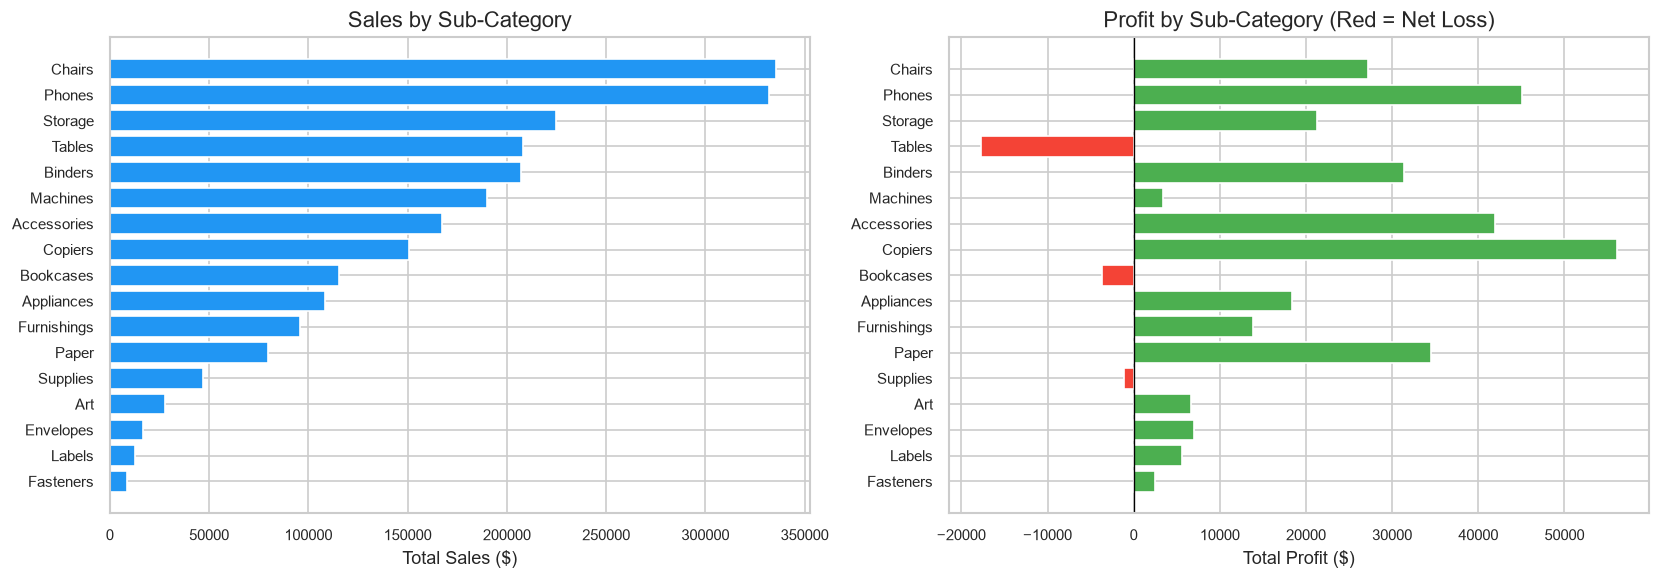

In [16]:
subcat_perf = orders.groupby('Sub-Category').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')
).reset_index().sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(subcat_perf['Sub-Category'], subcat_perf['Sales'], color='#2196F3')
axes[0].set_title('Sales by Sub-Category')
axes[0].set_xlabel('Total Sales ($)')
axes[0].invert_yaxis()

colors = ['#4CAF50' if p >= 0 else '#F44336' for p in subcat_perf['Profit']]
axes[1].barh(subcat_perf['Sub-Category'], subcat_perf['Profit'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Profit by Sub-Category (Red = Net Loss)')
axes[1].set_xlabel('Total Profit ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('product_analytics.png', dpi=120, bbox_inches='tight')
plt.show()

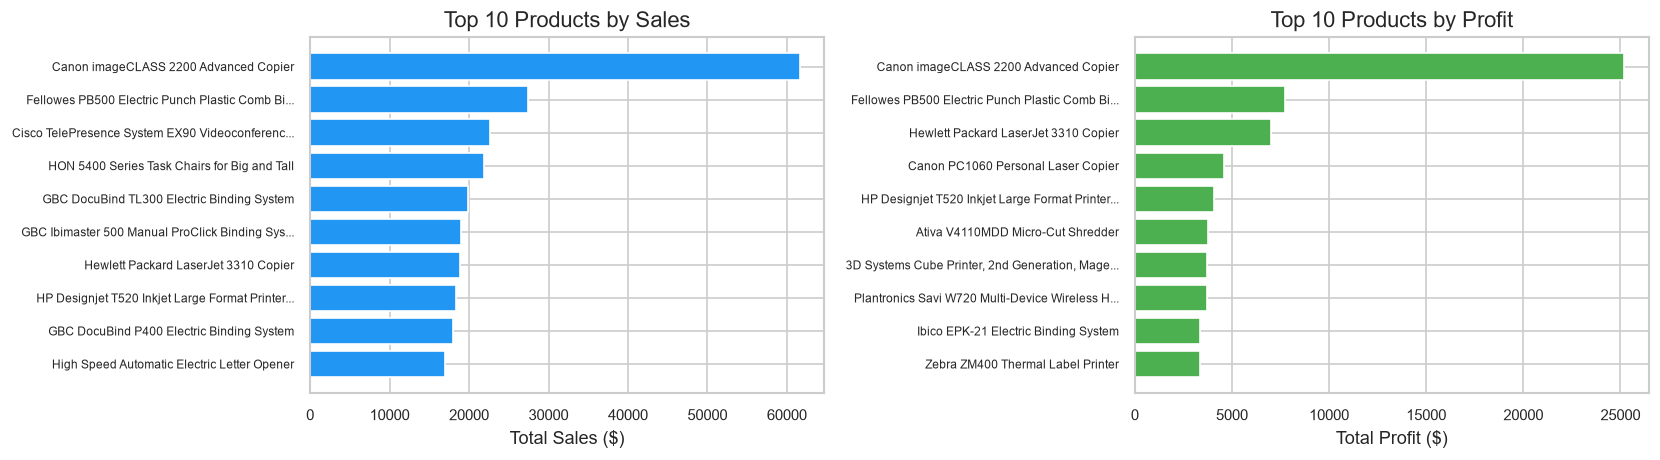

In [17]:
top_prod_sales  = orders.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()
top_prod_profit = orders.groupby('Product Name')['Profit'].sum().nlargest(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(range(10), top_prod_sales['Sales'].values, color='#2196F3')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([p[:45]+'...' if len(p)>45 else p for p in top_prod_sales['Product Name']], fontsize=7)
axes[0].set_title('Top 10 Products by Sales')
axes[0].set_xlabel('Total Sales ($)')
axes[0].invert_yaxis()

axes[1].barh(range(10), top_prod_profit['Profit'].values, color='#4CAF50')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([p[:45]+'...' if len(p)>45 else p for p in top_prod_profit['Product Name']], fontsize=7)
axes[1].set_title('Top 10 Products by Profit')
axes[1].set_xlabel('Total Profit ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_products.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** Technology leads in sales volume. Some Sub-Categories (Tables, Bookcases) show negative total profit — they are consistently sold at a loss, representing clear areas for pricing or discount strategy review.

## 17. Regional Analytics

In [18]:
region_perf = orders.groupby('Region').agg(
    Sales    =('Sales',    'sum'),
    Profit   =('Profit',   'sum'),
    Quantity =('Quantity', 'sum'),
    Discount =('Discount', 'mean'),
    Orders   =('Order ID', 'nunique'),
).reset_index()
region_perf['Margin'] = region_perf['Profit'] / region_perf['Sales']
print('Regional Performance:')
display(region_perf.style.format({
    'Sales': '${:,.0f}', 'Profit': '${:,.0f}',
    'Quantity': '{:,}', 'Discount': '{:.1%}', 'Margin': '{:.1%}'
}))

Regional Performance:


,Region,Sales,Profit,Quantity,Discount,Orders,Margin
0,Central,"$503,171","$39,865","8,820",24.1%,1179,7.9%
1,East,"$691,828","$94,883","11,159",14.3%,1475,13.7%
2,South,"$391,722","$46,749","6,209",14.7%,822,11.9%
3,West,"$739,814","$110,799","12,466",10.9%,1635,15.0%


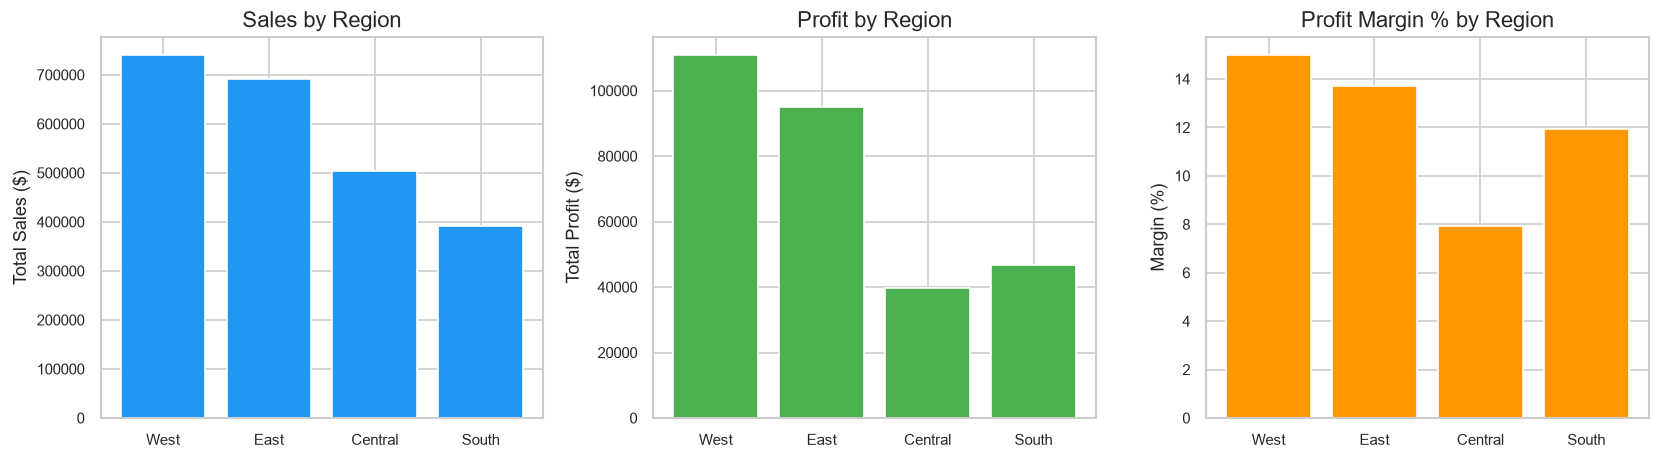

In [19]:
r = region_perf.sort_values('Sales', ascending=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(r['Region'], r['Sales'], color='#2196F3')
axes[0].set_title('Sales by Region')
axes[0].set_ylabel('Total Sales ($)')

axes[1].bar(r['Region'], r['Profit'],
            color=['#4CAF50' if p >= 0 else '#F44336' for p in r['Profit']])
axes[1].set_title('Profit by Region')
axes[1].set_ylabel('Total Profit ($)')

axes[2].bar(r['Region'], r['Margin'] * 100, color='#FF9800')
axes[2].set_title('Profit Margin % by Region')
axes[2].set_ylabel('Margin (%)')

plt.tight_layout()
plt.savefig('regional_analytics.png', dpi=120, bbox_inches='tight')
plt.show()

In [20]:
rm_perf = orders.groupby(['Region', 'Regional Manager']).agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')
).reset_index()
rm_perf['Margin'] = rm_perf['Profit'] / rm_perf['Sales']
print('Regional Manager Performance:')
display(rm_perf.sort_values('Sales', ascending=False))

Regional Manager Performance:


,Region,Regional Manager,Sales,Profit,Margin
3,West,Sadie Pawthorne,739813.6085,110798.8170,0.149766
1,East,Chuck Magee,691828.1680,94883.2603,0.137149
0,Central,Roxanne Rodriguez,503170.6728,39865.3070,0.079228
2,South,Fred Suzuki,391721.9050,46749.4303,0.119343


**Interpretation:** The West and East regions lead in sales volume. Profit margin varies by region — differences may reflect product mix, discount practices, or operational cost differences.

## 18. Discount and Profitability Analysis

> **Important:** The following is observational. Historical data shows associations between discount levels and profitability. No causal relationship is claimed.

In [21]:
bins   = [-0.001, 0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 1.01]
labels = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '>50%']
orders['Discount Band'] = pd.cut(orders['Discount'], bins=bins, labels=labels)

disc_prof = orders.groupby('Discount Band', observed=True).agg(
    Avg_Margin   =('Profit Margin', 'mean'),
    Total_Sales  =('Sales',         'sum'),
    Total_Profit =('Profit',        'sum'),
    Count        =('Sales',         'count'),
).reset_index()

print('Historical association: Discount Band vs Profitability')
display(disc_prof.style.format({
    'Avg_Margin':   '{:.1%}',
    'Total_Sales':  '${:,.0f}',
    'Total_Profit': '${:,.0f}',
    'Count':        '{:,}',
}))

Historical association: Discount Band vs Profitability


,Discount Band,Avg_Margin,Total_Sales,Total_Profit,Count
0,0%,34.1%,"$1,105,324","$326,719","4,925"
1,1-10%,15.5%,"$54,952","$9,100",96
2,11-20%,17.5%,"$801,498","$92,499","3,758"
3,21-30%,-11.6%,"$104,474","$-10,513",230
4,31-40%,-21.8%,"$130,991","$-25,478",234
5,41-50%,-53.6%,"$64,404","$-23,000",77
6,>50%,-113.0%,"$64,891","$-77,030",874


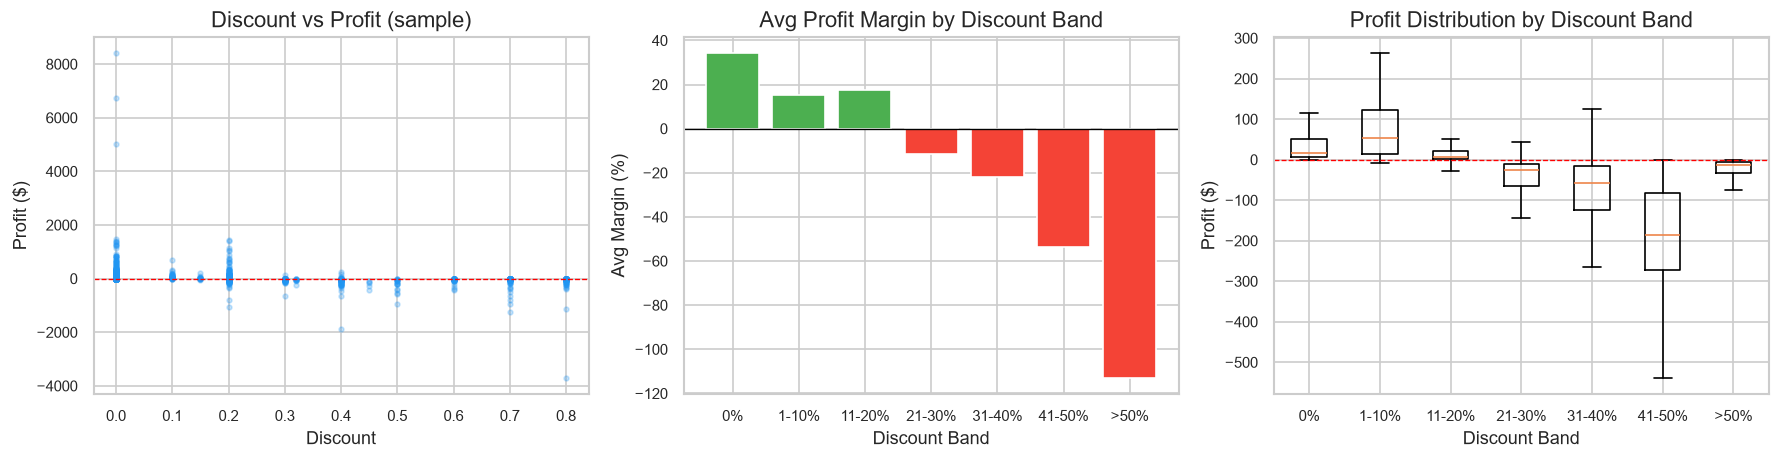

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_df = orders.sample(min(3000, len(orders)), random_state=RANDOM_STATE)
axes[0].scatter(sample_df['Discount'], sample_df['Profit'], alpha=0.25, s=8, color='#2196F3')
axes[0].axhline(0, color='red', lw=0.8, linestyle='--')
axes[0].set_title('Discount vs Profit (sample)')
axes[0].set_xlabel('Discount')
axes[0].set_ylabel('Profit ($)')

colors_disc = ['#4CAF50' if m >= 0 else '#F44336' for m in disc_prof['Avg_Margin']]
axes[1].bar(disc_prof['Discount Band'], disc_prof['Avg_Margin'] * 100, color=colors_disc)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Avg Profit Margin by Discount Band')
axes[1].set_xlabel('Discount Band')
axes[1].set_ylabel('Avg Margin (%)')

disc_data = [orders[orders['Discount Band'] == b]['Profit'].dropna().values for b in labels]
axes[2].boxplot(disc_data, tick_labels=labels, showfliers=False)
axes[2].axhline(0, color='red', lw=0.8, linestyle='--')
axes[2].set_title('Profit Distribution by Discount Band')
axes[2].set_xlabel('Discount Band')
axes[2].set_ylabel('Profit ($)')

plt.tight_layout()
plt.savefig('discount_profitability.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** Historical observations show that order lines with zero or low discounts tend to be associated with positive profit margins. Order lines with discounts above ~20-30% are historically associated with negative or near-zero margins. This is a data-supported association, not a causal claim.

## 19. Time-Series Sales Analysis

In [23]:
monthly = (
    orders.groupby('Year-Month')
    .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
    .reset_index()
)
monthly['Year-Month-dt'] = monthly['Year-Month'].dt.to_timestamp()
monthly = monthly.sort_values('Year-Month-dt').reset_index(drop=True)
monthly['Month_Index'] = np.arange(len(monthly))

print(f'Monthly time series: {len(monthly)} periods')
print(f'From {monthly["Year-Month-dt"].min().date()} to {monthly["Year-Month-dt"].max().date()}')

Monthly time series: 48 periods
From 2023-01-01 to 2026-12-01


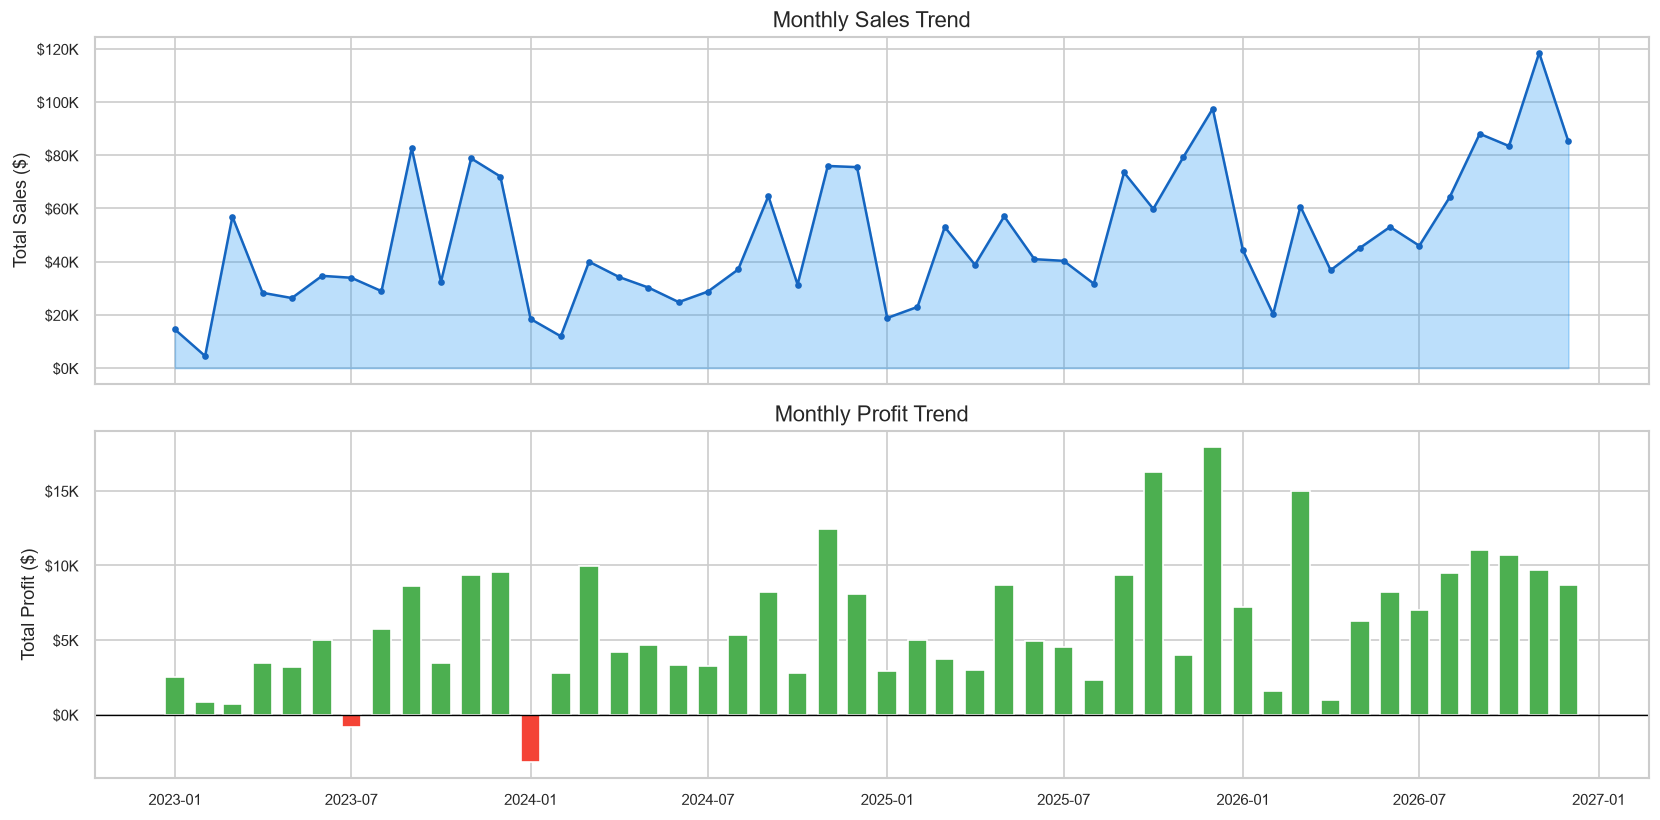

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].fill_between(monthly['Year-Month-dt'], monthly['Sales'], alpha=0.3, color='#2196F3')
axes[0].plot(monthly['Year-Month-dt'], monthly['Sales'],
             color='#1565C0', linewidth=1.5, marker='o', markersize=3)
axes[0].set_title('Monthly Sales Trend')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

colors_p = ['#4CAF50' if p >= 0 else '#F44336' for p in monthly['Profit']]
axes[1].bar(monthly['Year-Month-dt'], monthly['Profit'], color=colors_p, width=20)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Monthly Profit Trend')
axes[1].set_ylabel('Total Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('sales_trend.png', dpi=120, bbox_inches='tight')
plt.show()

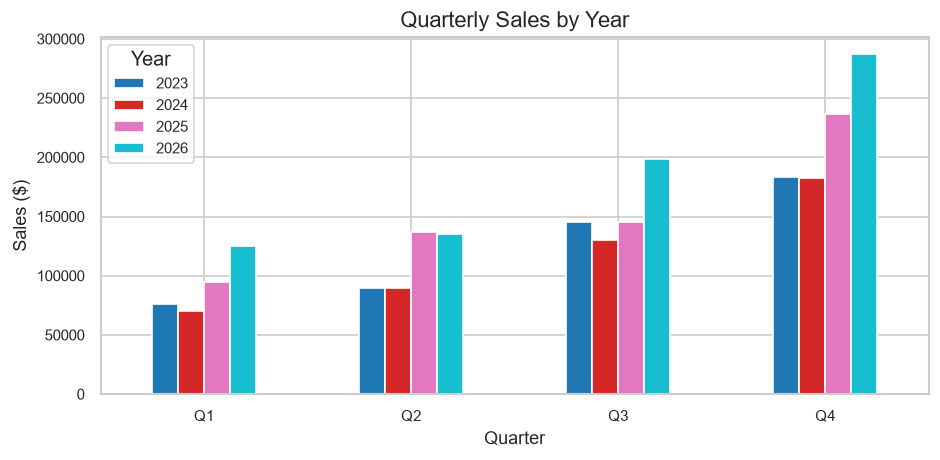

In [25]:
quarterly = orders.groupby(['Order Year','Order Quarter'])['Sales'].sum().reset_index()
pivot_q = quarterly.pivot(index='Order Quarter', columns='Order Year', values='Sales')

fig, ax = plt.subplots(figsize=(8, 4))
pivot_q.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Quarterly Sales by Year')
ax.set_xlabel('Quarter')
ax.set_ylabel('Sales ($)')
ax.set_xticklabels([f'Q{q}' for q in pivot_q.index], rotation=0)
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('quarterly_sales.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** Monthly sales show temporal variation. Quarterly analysis reveals whether consistent seasonal patterns exist (e.g., Q4 strength) across years.

## 20. Predictive Sales Analytics

> **Disclaimer:** Predictions are model-based estimates from historical patterns. They are not guarantees of future performance.

In [26]:
feat_df = monthly.copy()
feat_df['Month_Num']   = feat_df['Year-Month-dt'].dt.month
feat_df['Year_Num']    = feat_df['Year-Month-dt'].dt.year
feat_df['Quarter_Num'] = feat_df['Year-Month-dt'].dt.quarter
feat_df['Sales_Lag1']  = feat_df['Sales'].shift(1)
feat_df['Sales_Lag2']  = feat_df['Sales'].shift(2)
feat_df['Sales_Lag3']  = feat_df['Sales'].shift(3)
feat_df = feat_df.dropna().reset_index(drop=True)

FEATURES = ['Month_Index','Month_Num','Year_Num','Quarter_Num',
            'Sales_Lag1','Sales_Lag2','Sales_Lag3']
TARGET = 'Sales'

X = feat_df[FEATURES].values
y = feat_df[TARGET].values

split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 33
Test samples     : 12


In [27]:
# Baseline: previous month's sales
y_baseline_test = X_test[:, FEATURES.index('Sales_Lag1')]
baseline_mae  = mean_absolute_error(y_test, y_baseline_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_baseline_test))
print(f'Baseline (Lag-1) -- MAE: ${baseline_mae:,.0f}  RMSE: ${baseline_rmse:,.0f}')

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f'Linear Regression  -- MAE: ${lr_mae:,.0f}  RMSE: ${lr_rmse:,.0f}')

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200, max_depth=6,
    min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f'Random Forest      -- MAE: ${rf_mae:,.0f}  RMSE: ${rf_rmse:,.0f}')

Baseline (Lag-1) -- MAE: $23,320  RMSE: $27,467
Linear Regression  -- MAE: $12,968  RMSE: $16,384


Random Forest      -- MAE: $13,897  RMSE: $16,945

## 21. Model Evaluation

In [28]:
if rf_rmse <= lr_rmse:
    best_model_name = 'Random Forest'
    y_pred_best     = y_pred_rf
    best_mae        = rf_mae
    best_rmse       = rf_rmse
else:
    best_model_name = 'Linear Regression'
    y_pred_best     = y_pred_lr
    best_mae        = lr_mae
    best_rmse       = lr_rmse

mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred_best[mask]) / y_test[mask])) * 100

eval_df = pd.DataFrame({
    'Model':     ['Baseline (Lag-1)', 'Linear Regression', 'Random Forest'],
    'MAE ($)':   [f'{baseline_mae:,.0f}', f'{lr_mae:,.0f}', f'{rf_mae:,.0f}'],
    'RMSE ($)':  [f'{baseline_rmse:,.0f}', f'{lr_rmse:,.0f}', f'{rf_rmse:,.0f}'],
})
print(f'Best model: {best_model_name}')
print(f'MAE: ${best_mae:,.0f} | RMSE: ${best_rmse:,.0f} | MAPE: {mape:.1f}%')
print('\nModel Evaluation Summary:')
display(eval_df)

Best model: Linear Regression
MAE: $12,968 | RMSE: $16,384 | MAPE: 23.5%

Model Evaluation Summary:


,Model,MAE ($),RMSE ($)
0,Baseline (Lag-1),"23,320","27,467"
1,Linear Regression,"12,968","16,384"
2,Random Forest,"13,897","16,945"


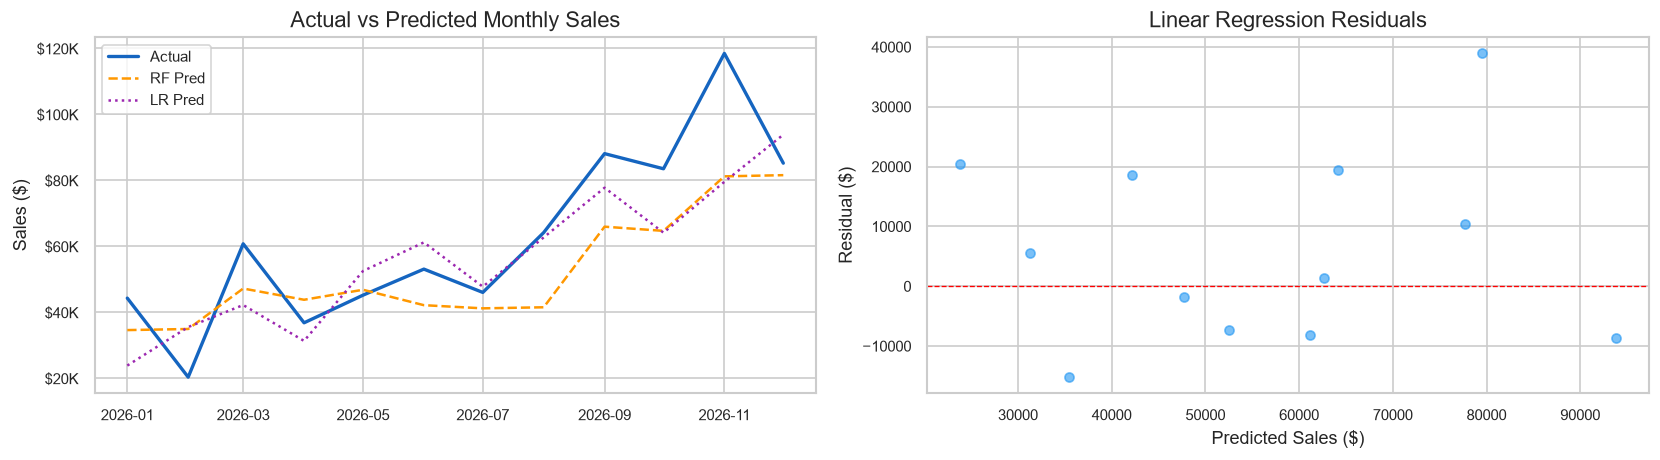

In [29]:
test_dates = feat_df['Year-Month-dt'].values[split_idx:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test_dates, y_test,    label='Actual',  color='#1565C0', lw=2)
axes[0].plot(test_dates, y_pred_rf, label='RF Pred', color='#FF9800', lw=1.5, ls='--')
axes[0].plot(test_dates, y_pred_lr, label='LR Pred', color='#9C27B0', lw=1.5, ls=':')
axes[0].set_title('Actual vs Predicted Monthly Sales')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, color='#2196F3', s=30)
axes[1].axhline(0, color='red', lw=0.8, linestyle='--')
axes[1].set_title(f'{best_model_name} Residuals')
axes[1].set_xlabel('Predicted Sales ($)')
axes[1].set_ylabel('Residual ($)')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

## 22. Model Explainability

> Feature importance indicates which features influence model predictions — not causal drivers of sales.

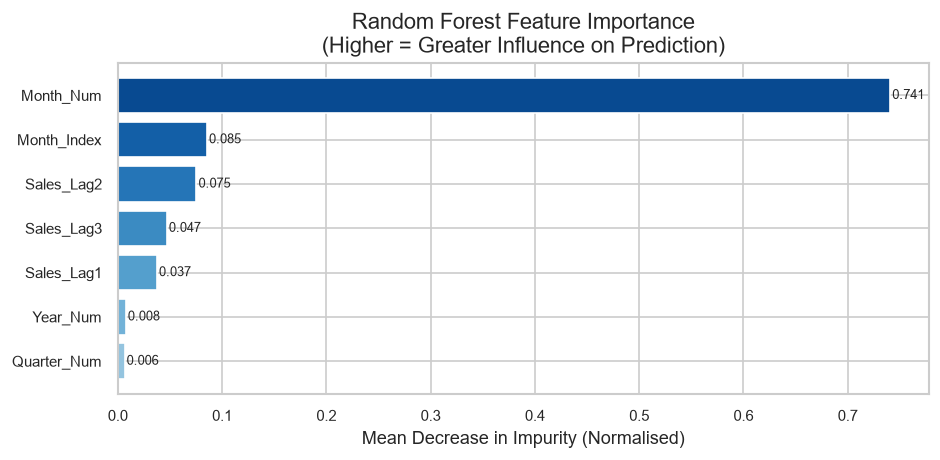


Note: Feature importance reflects model behaviour on historical data.
It does NOT prove causality.


In [30]:
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_fi = plt.cm.Blues(np.linspace(0.4, 0.9, len(fi_df)))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors_fi)
ax.set_title('Random Forest Feature Importance\n(Higher = Greater Influence on Prediction)')
ax.set_xlabel('Mean Decrease in Impurity (Normalised)')
for bar, val in zip(bars, fi_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nNote: Feature importance reflects model behaviour on historical data.')
print('It does NOT prove causality.')

**Interpretation:** Recent lag features (Sales_Lag1, Lag2, Lag3) are expected to be most informative — they capture sales momentum. Temporal features (Year, Month, Quarter) capture trend and seasonality.

## 23. Anomaly Detection

> **Definition:** An anomaly is an observation that differs substantially from the learned pattern. It is not automatically an error, fraud, or business problem — it may represent an extraordinary event, pricing exception, or legitimate outlier requiring investigation.

In [31]:
anomaly_features = ['Sales', 'Profit', 'Quantity', 'Discount']
X_anom = orders[anomaly_features].fillna(0).values

iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=RANDOM_STATE)
orders['Anomaly_Score'] = iso.fit_predict(X_anom)
orders['Is_Anomaly']    = (orders['Anomaly_Score'] == -1).astype(int)

n_anomalies = orders['Is_Anomaly'].sum()
print(f'Anomalous transactions detected: {n_anomalies:,} ({n_anomalies/len(orders)*100:.1f}%)')

Anomalous transactions detected: 306 (3.0%)


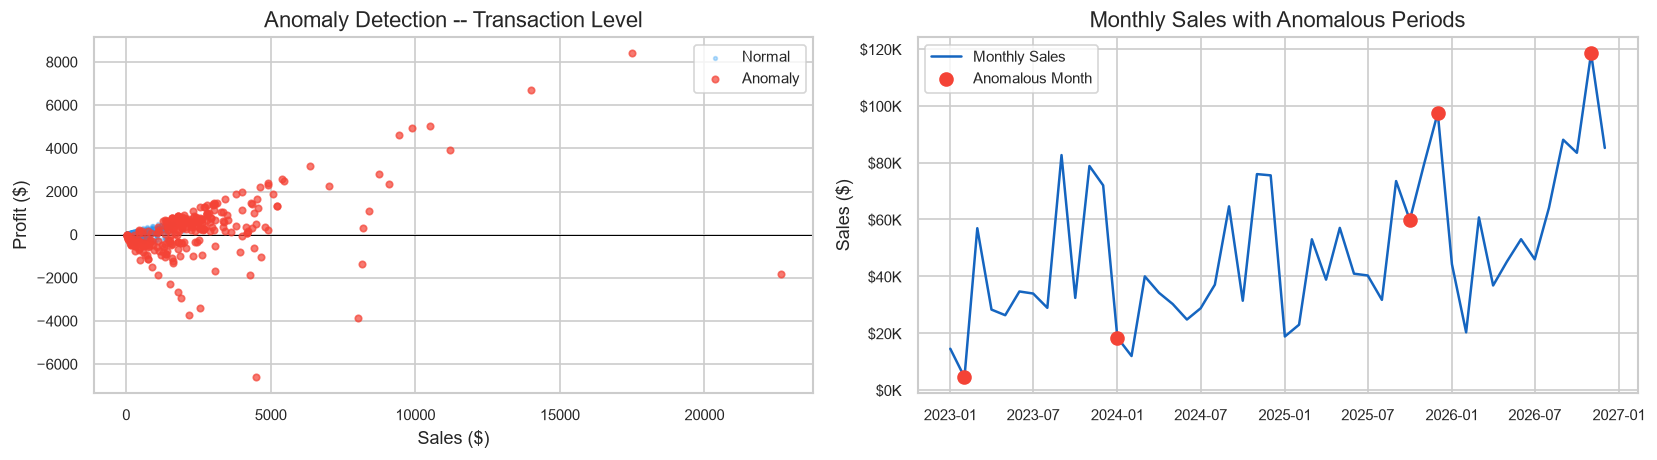

In [32]:
monthly_feat = monthly[['Sales','Profit']].fillna(0).values
iso_monthly  = IsolationForest(n_estimators=200, contamination=0.10, random_state=RANDOM_STATE)
monthly['Is_Anomaly'] = (iso_monthly.fit_predict(monthly_feat) == -1).astype(int)

normal    = orders[orders['Is_Anomaly'] == 0]
anomalous = orders[orders['Is_Anomaly'] == 1]
sample_n  = normal.sample(min(2000, len(normal)), random_state=RANDOM_STATE)
m_anom    = monthly[monthly['Is_Anomaly'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(sample_n['Sales'], sample_n['Profit'],
                s=5, alpha=0.3, color='#2196F3', label='Normal')
axes[0].scatter(anomalous['Sales'], anomalous['Profit'],
                s=15, alpha=0.7, color='#F44336', label='Anomaly', zorder=5)
axes[0].axhline(0, color='black', lw=0.6)
axes[0].set_title('Anomaly Detection -- Transaction Level')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Profit ($)')
axes[0].legend()

axes[1].plot(monthly['Year-Month-dt'], monthly['Sales'],
             color='#1565C0', lw=1.5, label='Monthly Sales')
axes[1].scatter(m_anom['Year-Month-dt'], m_anom['Sales'],
                color='#F44336', s=60, zorder=5, label='Anomalous Month')
axes[1].set_title('Monthly Sales with Anomalous Periods')
axes[1].set_ylabel('Sales ($)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=120, bbox_inches='tight')
plt.show()

In [33]:
print('Sample of anomalous transactions (top by Sales):')
display(anomalous[['Order ID','Order Date','Customer ID','Category',
                    'Sales','Profit','Quantity','Discount']]
        .sort_values('Sales', ascending=False).head(10))

Sample of anomalous transactions (top by Sales):


,Order ID,Order Date,Customer ID,Category,Sales,Profit,Quantity,Discount
226,US-2023-145317,2023-03-18,SM-20320,Technology,22638.480,-1811.0784,6,0.5
5894,US-2025-118689,2025-10-02,TC-20980,Technology,17499.950,8399.9760,5,0.0
7255,US-2026-140151,2026-03-23,RB-19360,Technology,13999.960,6719.9808,4,0.0
9171,US-2026-127180,2026-10-22,TA-21385,Technology,11199.968,3919.9888,4,0.2
9517,US-2026-166709,2026-11-17,HL-15040,Technology,10499.970,5039.9856,3,0.0
6674,US-2025-117121,2025-12-17,AB-10105,Office Supplies,9892.740,4946.3700,13,0.0
1203,US-2023-116904,2023-09-23,SC-20095,Office Supplies,9449.950,4630.4755,5,0.0
4624,US-2025-107440,2025-04-16,BS-11365,Technology,9099.930,2365.9818,7,0.0
4282,US-2025-158841,2025-02-02,SE-20110,Technology,8749.950,2799.9840,5,0.0
4845,US-2025-143714,2025-05-23,CC-12370,Technology,8399.976,1119.9968,4,0.4


## 24. Business Risk Analysis

In [34]:
print('=== BUSINESS RISK INDICATORS ===\n')

# Risk 1: High-discount loss-making lines
hd_loss = orders[(orders['Discount'] >= 0.30) & (orders['Profit'] < 0)]
print(f'[RISK 1] High Discount (>=30%) + Loss lines:')
print(f'  Lines: {len(hd_loss):,} | Profit Impact: ${hd_loss["Profit"].sum():,.0f}\n')

# Risk 2: Loss-making sub-categories
loss_sc = (orders.groupby('Sub-Category')['Profit'].sum()
           .where(lambda x: x < 0).dropna().sort_values())
print('[RISK 2] Sub-Categories with Negative Total Profit:')
for sc, p in loss_sc.items():
    print(f'  {sc}: ${p:,.0f}')

# Risk 3: Below-median margin regions
med = orders['Profit Margin'].median()
low_r = (orders.groupby('Region')['Profit Margin'].median()
         .where(lambda x: x < med).dropna())
print(f'\n[RISK 3] Regions with Below-Median Margin (median={med:.1%}):')
for reg, m in low_r.items():
    print(f'  {reg}: {m:.1%}')

print(f'\n[RISK 4] Anomalous transactions: {n_anomalies:,} (require investigation)')
print('\nNOTE: These are data-supported indicators, not proof of problems or fraud.')

=== BUSINESS RISK INDICATORS ===

[RISK 1] High Discount (>=30%) + Loss lines:
  Lines: 1,370 | Profit Impact: $-139,160

[RISK 2] Sub-Categories with Negative Total Profit:
  Tables: $-17,753
  Bookcases: $-3,632
  Supplies: $-1,171

[RISK 3] Regions with Below-Median Margin (median=27.0%):
  Central: 18.0%
  South: 26.3%

[RISK 4] Anomalous transactions: 306 (require investigation)

NOTE: These are data-supported indicators, not proof of problems or fraud.


## 25. Returns Analysis

In [35]:
n_returned  = len(returned_order_ids)
n_total_ord = orders['Order ID'].nunique()
return_rate = n_returned / n_total_ord

print(f'Returned orders (from Returns sheet): {n_returned:,}')
print(f'Total unique orders                  : {n_total_ord:,}')
print(f'Order-level return rate              : {return_rate:.1%}')
print('\nNOTE: Return rate is measured at the ORDER level (unique Order IDs).')

Returned orders (from Returns sheet): 296
Total unique orders                  : 5,111
Order-level return rate              : 5.8%

NOTE: Return rate is measured at the ORDER level (unique Order IDs).


In [36]:
order_summary = orders.drop_duplicates(subset='Order ID')[[
    'Order ID', 'Category', 'Region', 'Segment', 'Is Returned'
]]

def return_rate_by(col):
    g = order_summary.groupby(col)['Is Returned'].agg(['sum','count'])
    g.columns = ['Returned','Total']
    g['Return Rate'] = g['Returned'] / g['Total']
    return g.reset_index().sort_values('Return Rate', ascending=False)

print('Return Rate by Category:')
display(return_rate_by('Category'))
print('\nReturn Rate by Region:')
display(return_rate_by('Region'))
print('\nReturn Rate by Segment:')
display(return_rate_by('Segment'))

Return Rate by Category:


,Category,Returned,Total,Return Rate
0,Furniture,136,1819,0.074766
1,Office Supplies,141,2814,0.050107
2,Technology,19,478,0.039749



Return Rate by Region:


,Region,Returned,Total,Return Rate
3,West,189,1635,0.115596
0,Central,39,1179,0.033079
1,East,44,1475,0.029831
2,South,24,822,0.029197



Return Rate by Segment:


,Segment,Returned,Total,Return Rate
1,Corporate,93,1552,0.059923
0,Consumer,154,2628,0.058600
2,Home Office,49,931,0.052632


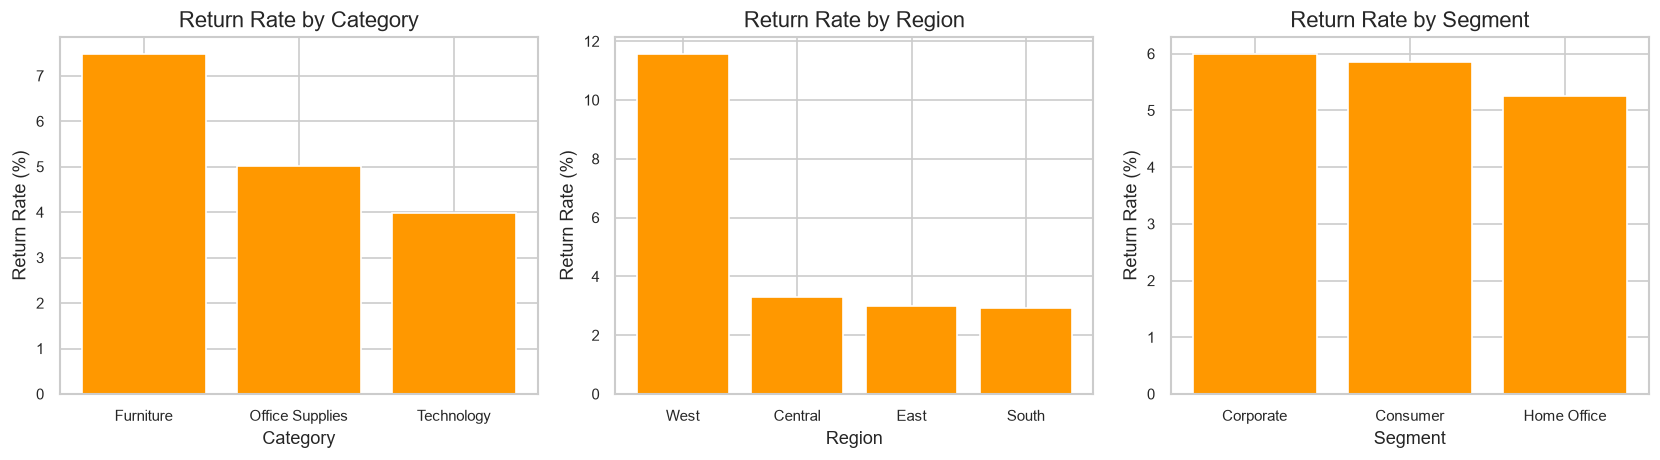

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(
    axes,
    ['Category','Region','Segment'],
    ['Return Rate by Category','Return Rate by Region','Return Rate by Segment']
):
    rr = return_rate_by(col)
    ax.bar(rr[col], rr['Return Rate'] * 100, color='#FF9800')
    ax.set_title(title)
    ax.set_ylabel('Return Rate (%)')
    ax.set_xlabel(col)
plt.tight_layout()
plt.savefig('returns_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** The order-level return rate provides a comparable metric across dimensions. Differences may reflect product quality, customer expectation gaps, or logistics issues.

## 26. InsightIQ Decision Simulator

> **IMPORTANT:** This simulator produces model-based scenario estimates from historical data. It does not model causal mechanisms. Estimates are scenario projections, not guarantees. All outputs should be reviewed with domain expertise before business decisions are made.

In [38]:
sim_df = orders[['Sales','Profit','Quantity','Discount','Category','Region','Segment']].copy().dropna()

le_cat = LabelEncoder()
le_reg = LabelEncoder()
le_seg = LabelEncoder()
sim_df = sim_df.copy()
sim_df['Cat_Enc'] = le_cat.fit_transform(sim_df['Category'])
sim_df['Reg_Enc'] = le_reg.fit_transform(sim_df['Region'])
sim_df['Seg_Enc'] = le_seg.fit_transform(sim_df['Segment'])

SIM_FEATURES = ['Discount','Quantity','Cat_Enc','Reg_Enc','Seg_Enc']
sim_df = sim_df.reset_index(drop=True)
split_sim = int(len(sim_df) * 0.80)

X_sim_all = sim_df[SIM_FEATURES].values
X_sim_tr, X_sim_te = X_sim_all[:split_sim], X_sim_all[split_sim:]
y_sales_tr  = sim_df['Sales'].values[:split_sim]
y_sales_te  = sim_df['Sales'].values[split_sim:]
y_profit_tr = sim_df['Profit'].values[:split_sim]
y_profit_te = sim_df['Profit'].values[split_sim:]

rf_s = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf_p = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf_s.fit(X_sim_tr, y_sales_tr)
rf_p.fit(X_sim_tr, y_profit_tr)

print(f'Simulator Sales Model  MAE: ${mean_absolute_error(y_sales_te,  rf_s.predict(X_sim_te)):.2f}')
print(f'Simulator Profit Model MAE: ${mean_absolute_error(y_profit_te, rf_p.predict(X_sim_te)):.2f}')

Simulator Sales Model  MAE: $226.73
Simulator Profit Model MAE: $68.94


In [39]:
def run_scenario(discount_rate, label, category='Technology',
                 region='West', segment='Consumer', quantity=3):
    cat_enc = le_cat.transform([category])[0]
    reg_enc = le_reg.transform([region])[0]
    seg_enc = le_seg.transform([segment])[0]
    x = np.array([[discount_rate, quantity, cat_enc, reg_enc, seg_enc]])
    est_sales  = rf_s.predict(x)[0]
    est_profit = rf_p.predict(x)[0]
    return {
        'Scenario':        label,
        'Discount':        discount_rate,
        'Est. Sales ($)':  est_sales,
        'Est. Profit ($)': est_profit,
        'Est. Margin':     est_profit / est_sales if est_sales != 0 else 0.0,
    }

SCENARIOS = [
    (0.00, 'No Discount (0%)'),
    (0.10, 'Low Discount (10%)'),
    (0.20, 'Moderate Discount (20%)'),
    (0.30, 'High Discount (30%)'),
    (0.50, 'Heavy Discount (50%)'),
]

results = [run_scenario(d, lbl) for d, lbl in SCENARIOS]
sim_table = pd.DataFrame(results)
bl_sales  = sim_table.loc[0,'Est. Sales ($)']
bl_profit = sim_table.loc[0,'Est. Profit ($)']
sim_table['Delta Sales ($)']  = sim_table['Est. Sales ($)']  - bl_sales
sim_table['Delta Profit ($)'] = sim_table['Est. Profit ($)'] - bl_profit

print('InsightIQ Decision Simulator -- Scenario Results')
print('Context: Technology | West | Consumer | Qty=3')
print('NOTE: Model-based projections from historical data. Not causal guarantees.')
print()
display(sim_table.style.format({
    'Discount':         '{:.0%}',
    'Est. Sales ($)':   '${:.2f}',
    'Est. Profit ($)':  '${:.2f}',
    'Est. Margin':      '{:.1%}',
    'Delta Sales ($)':  '${:+.2f}',
    'Delta Profit ($)': '${:+.2f}',
}))

InsightIQ Decision Simulator -- Scenario Results
Context: Technology | West | Consumer | Qty=3
NOTE: Model-based projections from historical data. Not causal guarantees.



,Scenario,Discount,Est. Sales ($),Est. Profit ($),Est. Margin,Delta Sales ($),Delta Profit ($)
0,No Discount (0%),0%,$349.38,$103.79,29.7%,$+0.00,$+0.00
1,Low Discount (10%),10%,$518.27,$375.99,72.5%,$+168.90,$+272.21
2,Moderate Discount (20%),20%,$310.73,$46.95,15.1%,$-38.64,$-56.84
3,High Discount (30%),30%,$391.52,$-102.90,-26.3%,$+42.14,$-206.68
4,Heavy Discount (50%),50%,$987.95,$-439.22,-44.5%,$+638.57,$-543.01


## 27. Scenario Comparison

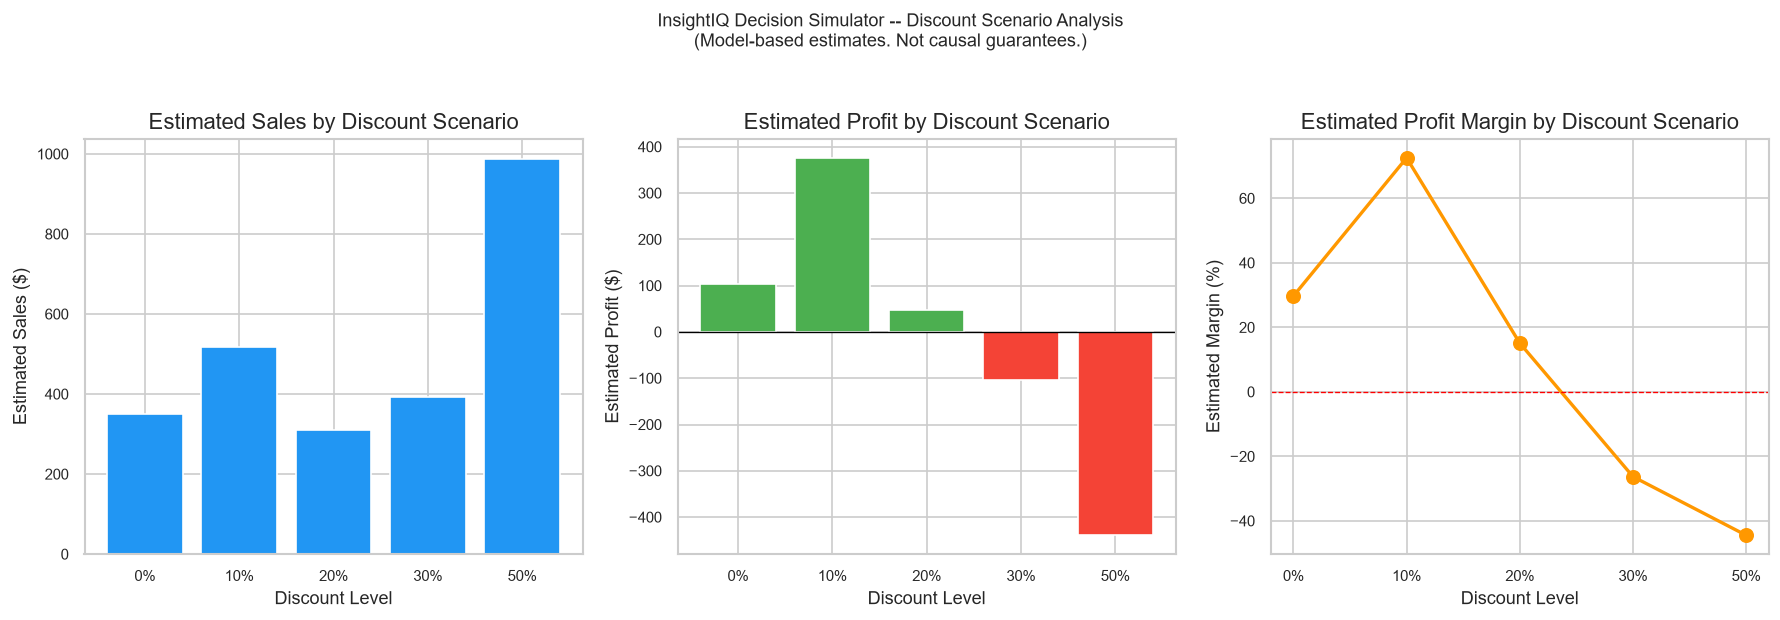

In [40]:
short_labels = [f'{d*100:.0f}%' for d, _ in SCENARIOS]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(short_labels, sim_table['Est. Sales ($)'], color='#2196F3')
axes[0].set_title('Estimated Sales by Discount Scenario')
axes[0].set_xlabel('Discount Level')
axes[0].set_ylabel('Estimated Sales ($)')

p_colors = ['#4CAF50' if p >= 0 else '#F44336' for p in sim_table['Est. Profit ($)']]
axes[1].bar(short_labels, sim_table['Est. Profit ($)'], color=p_colors)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Estimated Profit by Discount Scenario')
axes[1].set_xlabel('Discount Level')
axes[1].set_ylabel('Estimated Profit ($)')

axes[2].plot(short_labels, sim_table['Est. Margin'] * 100,
             marker='o', color='#FF9800', lw=2, markersize=8)
axes[2].axhline(0, color='red', lw=0.8, linestyle='--')
axes[2].set_title('Estimated Profit Margin by Discount Scenario')
axes[2].set_xlabel('Discount Level')
axes[2].set_ylabel('Estimated Margin (%)')

plt.suptitle(
    'InsightIQ Decision Simulator -- Discount Scenario Analysis\n'
    '(Model-based estimates. Not causal guarantees.)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig('scenario_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** Under model and historical-data assumptions, higher discount scenarios are associated with lower estimated profit per transaction. Actual outcomes depend on factors beyond this model's scope.

## 28. Key Findings

In [41]:
print('=== SECTION A: OBSERVED FINDINGS (from historical data) ===')
print(f"""
1. Historical data shows total sales of ${total_sales:,.0f} across
   {num_orders:,} unique orders from {num_customers:,} customers (2023-2026).

2. Historical data shows an overall profit margin of {overall_margin:.1%}.

3. Historical data shows Technology is the highest-revenue category;
   certain Sub-Categories (Tables, Bookcases) report negative total profit.

4. Historical data shows that lines with discounts >=30% are predominantly
   associated with negative profit values.

5. Historical data shows {n_returned:,} returned orders
   ({return_rate:.1%} order-level return rate).
""")

print('=== SECTION B: PREDICTIVE FINDINGS (model estimates) ===')
print(f"""
6. The {best_model_name} model estimates monthly sales
   with test MAE ${best_mae:,.0f} and RMSE ${best_rmse:,.0f}.

7. Recent sales lag features are the most influential predictors
   in the model (feature importance -- not causality).
""")

print('=== SECTION C: ANOMALY FINDINGS ===')
print(f"""
8. Isolation Forest identified {n_anomalies:,} transaction-level anomalies
   ({n_anomalies/len(orders)*100:.1f}% of transactions) requiring business investigation.
""")

print('=== SECTION D: SCENARIO ESTIMATES (simulator) ===')
print("""
9. Under model and historical-data assumptions, higher discount scenarios
   are associated with lower estimated profit per transaction.
   These are scenario projections, not causal guarantees.
""")

=== SECTION A: OBSERVED FINDINGS (from historical data) ===

1. Historical data shows total sales of $2,326,534 across
   5,111 unique orders from 804 customers (2023-2026).

2. Historical data shows an overall profit margin of 12.6%.

3. Historical data shows Technology is the highest-revenue category;
   certain Sub-Categories (Tables, Bookcases) report negative total profit.

4. Historical data shows that lines with discounts >=30% are predominantly
   associated with negative profit values.

5. Historical data shows 296 returned orders
   (5.8% order-level return rate).

=== SECTION B: PREDICTIVE FINDINGS (model estimates) ===

6. The Linear Regression model estimates monthly sales
   with test MAE $12,968 and RMSE $16,384.

7. Recent sales lag features are the most influential predictors
   in the model (feature importance -- not causality).

=== SECTION C: ANOMALY FINDINGS ===

8. Isolation Forest identified 306 transaction-level anomalies
   (3.0% of transactions) requiring busi

## 29. Business Recommendations

In [42]:
print("""
InsightIQ -- Data-Supported Business Recommendations
=====================================================

R1. DISCOUNT STRATEGY REVIEW
    Historical data shows transactions with discounts >=30% are predominantly
    loss-making. Review high-discount authorisation processes, particularly
    for Furniture and Office Supplies categories.

R2. SUB-CATEGORY PROFITABILITY INVESTIGATION
    Sub-categories with negative total profit (e.g., Tables, Bookcases)
    warrant pricing, costing, or product portfolio review.

R3. ANOMALY INVESTIGATION
    Anomalous transactions should be reviewed to determine root causes
    (exceptional deals, pricing errors, or data quality issues).

R4. RETURN RATE MONITORING
    Track order-level return rate as a KPI. High-return areas warrant
    customer feedback review and supply-chain investigation.

R5. REGIONAL PERFORMANCE ALIGNMENT
    Regions with below-median margins should be investigated for
    discount practices, product mix, and operational costs.

R6. FORECASTING INTEGRATION
    The predictive model can support planning and inventory decisions.
    Retrain on new data regularly and monitor performance.

IMPORTANT: All recommendations require human review before implementation.
Historical patterns do not guarantee future results.
""")


InsightIQ -- Data-Supported Business Recommendations

R1. DISCOUNT STRATEGY REVIEW
    Historical data shows transactions with discounts >=30% are predominantly
    loss-making. Review high-discount authorisation processes, particularly
    for Furniture and Office Supplies categories.

R2. SUB-CATEGORY PROFITABILITY INVESTIGATION
    Sub-categories with negative total profit (e.g., Tables, Bookcases)
    warrant pricing, costing, or product portfolio review.

R3. ANOMALY INVESTIGATION
    Anomalous transactions should be reviewed to determine root causes
    (exceptional deals, pricing errors, or data quality issues).

R4. RETURN RATE MONITORING
    Track order-level return rate as a KPI. High-return areas warrant
    customer feedback review and supply-chain investigation.

R5. REGIONAL PERFORMANCE ALIGNMENT
    Regions with below-median margins should be investigated for
    discount practices, product mix, and operational costs.

R6. FORECASTING INTEGRATION
    The predictive mode

## 30. Limitations

1. All findings are observational — no causal claims can be made.
2. The time-series model uses a limited number of monthly observations.
3. The Decision Simulator operates at order-line level; real discount changes affect complex customer behaviour.
4. Isolation Forest contamination (3%) is an assumption requiring sensitivity analysis.
5. Returns data provides Order ID only — no return reasons or costs available.
6. Dataset covers US and Canada only; findings may not generalise elsewhere.
7. No external macroeconomic or competitive data is included.

## 31. Future Scope

1. ARIMA/Prophet/LSTM for advanced time-series forecasting
2. SHAP values for per-prediction interpretability
3. Customer Lifetime Value (CLV) modelling
4. RFM-based customer churn prediction
5. Price elasticity modelling with quasi-experimental methods
6. Streamlit interactive dashboard deployment
7. State-level geospatial choropleth visualisations

## 32. Conclusion

InsightIQ demonstrates a complete, end-to-end business intelligence pipeline applied to the official Tableau Sample Superstore dataset. The platform progresses from raw data through EDA, predictive modelling, explainability, anomaly detection, returns analysis, and what-if simulation — providing data-supported business intelligence while maintaining rigorous academic standards by clearly distinguishing observed findings, model predictions, and scenario estimates.

In [43]:
print('InsightIQ notebook execution complete.')
pngs = sorted([f for f in os.listdir('.') if f.endswith('.png')])
print(f'Output charts saved ({len(pngs)}):')
for f in pngs:
    print(f'  {f}')

InsightIQ notebook execution complete.
Output charts saved (13):
  anomaly_detection.png
  customer_analytics.png
  discount_profitability.png
  feature_importance.png
  kpi_dashboard.png
  model_evaluation.png
  product_analytics.png
  quarterly_sales.png
  regional_analytics.png
  returns_analysis.png
  sales_trend.png
  scenario_comparison.png
  top_products.png
